In [1]:
import pandas as pd
cust_info = pd.read_csv("../data/cleaned_churn.csv")
cust_info.head()
cust_info.shape


(7043, 20)

In [2]:
cust_info.dtypes

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

### Converting all data types to binary

In [3]:
cust_info = pd.read_csv('../data/cleaned_churn.csv')

from sklearn.preprocessing import LabelEncoder

binary_cols = ['gender','Partner','Dependents','PhoneService','MultipleLines',
               'OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport',
               'StreamingTV','StreamingMovies','PaperlessBilling']

le = LabelEncoder()
for col in binary_cols:
    cust_info[col] = le.fit_transform(cust_info[col].astype(str))

cust_info = pd.get_dummies(cust_info, columns=['Contract','InternetService','PaymentMethod'])

print(cust_info.dtypes)


gender                                       int64
SeniorCitizen                                int64
Partner                                      int64
Dependents                                   int64
tenure                                       int64
PhoneService                                 int64
MultipleLines                                int64
OnlineSecurity                               int64
OnlineBackup                                 int64
DeviceProtection                             int64
TechSupport                                  int64
StreamingTV                                  int64
StreamingMovies                              int64
PaperlessBilling                             int64
MonthlyCharges                             float64
TotalCharges                               float64
Churn                                        int64
Contract_Month-to-month                       bool
Contract_One year                             bool
Contract_Two year              

### Splitting the data into training and testing data

In [4]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = cust_info.drop('Churn', axis=1)
y = cust_info['Churn']

np.random.seed(42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

X_train_sc,X_test_sc

(array([[ 0.99433624, -0.44177295, -0.96923413, ..., -0.52380561,
          1.40690298, -0.54384572],
        [ 0.99433624, -0.44177295,  1.03174245, ..., -0.52380561,
         -0.71078107,  1.83875676],
        [ 0.99433624, -0.44177295,  1.03174245, ..., -0.52380561,
         -0.71078107,  1.83875676],
        ...,
        [-1.00569602,  2.2636062 , -0.96923413, ..., -0.52380561,
         -0.71078107,  1.83875676],
        [-1.00569602, -0.44177295,  1.03174245, ...,  1.90910518,
         -0.71078107, -0.54384572],
        [ 0.99433624, -0.44177295, -0.96923413, ..., -0.52380561,
         -0.71078107,  1.83875676]], shape=(5634, 26)),
 array([[ 0.99433624, -0.44177295,  1.03174245, ...,  1.90910518,
         -0.71078107, -0.54384572],
        [-1.00569602,  2.2636062 , -0.96923413, ...,  1.90910518,
         -0.71078107, -0.54384572],
        [-1.00569602, -0.44177295,  1.03174245, ...,  1.90910518,
         -0.71078107, -0.54384572],
        ...,
        [ 0.99433624, -0.44177295, -

### Instanting, fitting and testing the models

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, accuracy_score

np.random.seed(42)
models={
    "RFC" : RandomForestClassifier(),
    "LR" : LogisticRegression(),
    "KNC" : KNeighborsClassifier(),
    "SVmodel" : SVC(probability=True),
    "Xgb" : XGBClassifier() 
}

results=[]

for name,model in models.items():
    model.fit(X_train_sc,y_train)
    y_preds = model.predict(X_test_sc)
    y_probs = model.predict_proba(X_test_sc)[:, 1]

    results.append({
        "Model" : name,
        "Accuracy" : accuracy_score(y_test,y_preds),
        "AUC-ROC" : roc_auc_score(y_test, y_probs)
    })

results_df = pd.DataFrame(results).sort_values('AUC-ROC', ascending=False).reset_index(drop=True)
results_df

C:\Users\acer\AppData\Roaming\Python\Python314\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,Model,Accuracy,AUC-ROC
0,LR,0.806246,0.841807
1,RFC,0.786373,0.823524
2,Xgb,0.784244,0.819626
3,SVmodel,0.786373,0.798642
4,KNC,0.754436,0.773365


##### The best performing model out of all is Logistic Regression. It means the churn patterns in this data are largely linear (simpler relationships), so a simple model handles it well.

In [6]:
LR = LogisticRegression()
params = LR.get_params()
params

{'C': 1.0,
 'class_weight': None,
 'dual': False,
 'fit_intercept': True,
 'intercept_scaling': 1,
 'l1_ratio': 0.0,
 'max_iter': 100,
 'n_jobs': None,
 'penalty': 'deprecated',
 'random_state': None,
 'solver': 'lbfgs',
 'tol': 0.0001,
 'verbose': 0,
 'warm_start': False}

### Tuning the model

In [7]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression

params = {
    'C'          : [0.01, 0.1, 1, 10, 100],
    'penalty'    : ['l1', 'l2'],
    'solver'     : ['liblinear', 'saga'],
    'max_iter'   : [100, 500, 1000]
}

grid = GridSearchCV(
    LogisticRegression(),
    params,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1
)

grid.fit(X_train_sc, y_train)

print("Best parameters:", grid.best_params_)
print("Best CV AUC-ROC:", grid.best_score_)

C:\Users\acer\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1403: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', l1_ratio set to a float between 0 and 1 instead of penalty='elasticnet', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\acer\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:1429: UserWarning: Inconsistent values: penalty=l1 with l1_ratio=0.0. penalty is deprecated. Please use l1_ratio only.
  warnings.warn(


Best parameters: {'C': 100, 'max_iter': 100, 'penalty': 'l1', 'solver': 'saga'}
Best CV AUC-ROC: 0.8459349883212068


C:\Users\acer\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


GridSearchCV Results — Logistic Regression Tuning

Best parameters found: C=10, penalty='l1', solver='liblinear', max_iter=1000
* C=10 indicates weak regularization performed best, suggesting the dataset is clean and well-structured enough for the model to fit it more closely without overfitting.
* penalty='l1' (Lasso) won over l2, meaning some encoded features had little to no predictive value for churn — l1 automatically zeroed these out, producing a leaner, more interpretable model.
* solver='liblinear' was the optimal solver, consistent with expectations for a small binary classification dataset (~7,000 rows).
* max_iter=1000 confirms the model required full iterations to converge — lower values like 100 or 500 would have produced premature convergence warnings and suboptimal weights.
* Best cross-validated AUC-ROC: 0.8459 — an improvement over the baseline Logistic Regression score of 0.8418, confirming that hyperparameter tuning produced a meaningful, if modest, performance gain. The model was evaluated using 5-fold cross-validation on the training set, ensuring the score is a reliable estimate of generalization performance rather than a result of a single lucky split.

### Overall Evaluations

In [8]:
from sklearn.metrics import classification_report, confusion_matrix, RocCurveDisplay

best_lr = grid.best_estimator_

y_pred = best_lr.predict(X_test_sc)
y_prob = best_lr.predict_proba(X_test_sc)[:, 1]

print("Tuned LR Accuracy :", round(accuracy_score(y_test, y_pred), 4))
print("Tuned LR AUC-ROC  :", round(roc_auc_score(y_test, y_prob), 4))
print()
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

Tuned LR Accuracy : 0.8027
Tuned LR AUC-ROC  : 0.8409

              precision    recall  f1-score   support

    No Churn       0.85      0.89      0.87      1035
       Churn       0.65      0.55      0.60       374

    accuracy                           0.80      1409
   macro avg       0.75      0.72      0.73      1409
weighted avg       0.79      0.80      0.80      1409



### Confusion matrix

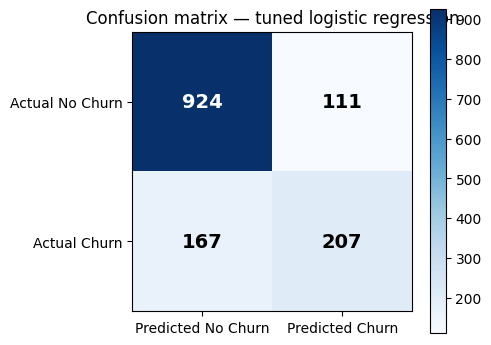

In [9]:
%matplotlib inline
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')

ax.set_xticks([0, 1]); ax.set_xticklabels(['Predicted No Churn', 'Predicted Churn'])
ax.set_yticks([0, 1]); ax.set_yticklabels(['Actual No Churn', 'Actual Churn'])

for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha='center', va='center', 
                color='white' if cm[i, j] > cm.max()/2 else 'black',
                fontsize=14, fontweight='bold')

fig.colorbar(im)
plt.title('Confusion matrix — tuned logistic regression')
plt.tight_layout()
plt.show()

### Confusion Matrix Breakdown:
* True Negatives (924) — customers who actually stayed and the model correctly predicted they'd stay. The model handles this majority class well.
* True Positives (207) — customers who actually churned and the model correctly caught them. These are the valuable catches — the customers a business could proactively reach out to.
* False Positives (111) — customers who actually stayed but the model flagged as churners. These are unnecessary interventions — the business would waste resources reaching out to loyal customers. Relatively low, which is good.
* False Negatives (167) — customers who actually churned but the model missed, predicting they'd stay. These are the most costly errors — churners the business had no chance to retain because the model didn't flag them. At 167, this is the main area for improvement.

Overall: out of 374 actual churners in the test set, the model correctly identified 207 (55.3% recall on churn class) while missing 167. For a baseline tuned Logistic Regression without any class imbalance handling, this is a reasonable starting point.

### ROC Curve

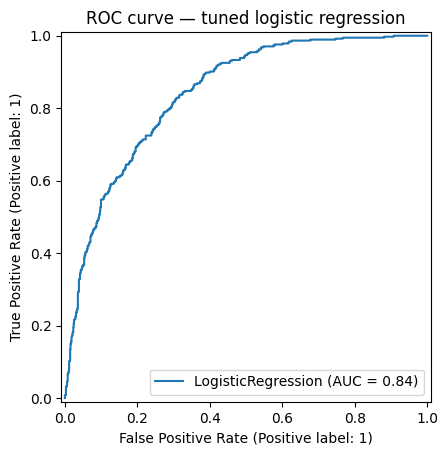

In [10]:
RocCurveDisplay.from_estimator(best_lr, X_test_sc, y_test)
plt.title('ROC curve — tuned logistic regression')
plt.show()

The ROC curve plots True Positive Rate (how many actual churners we caught) against False Positive Rate (how many non-churners we wrongly flagged) across every possible decision threshold.
* AUC = 0.84 — the area under this curve. An AUC of 0.5 would mean the model is no better than random guessing (a straight diagonal line). An AUC of 1.0 would be a perfect model. Our score of 0.84 means the model has strong discriminative ability — it can meaningfully separate churners from non-churners 84% of the time.
The curve hugs the top-left corner well, especially in the 0.0–0.4 False Positive Rate range, meaning the model is particularly good at catching churners while keeping false alarms low when operating at stricter thresholds.
* Key business takeaway: at the default 0.5 decision threshold, the model catches 55% of churners. A business could lower this threshold (say to 0.3) to catch more churners at the cost of more false alarms — the ROC curve shows exactly what that tradeoff looks like at every possible threshold, giving the business flexibility to choose based on their own cost-benefit analysis.

## Shap Explainer

In [11]:
import shap

explainer = shap.LinearExplainer(best_lr, X_train_sc)
shap_values = explainer.shap_values(X_test_sc)

Background dataset has 5634 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=5634 when initializing the masker.


C:\Users\acer\AppData\Local\Temp\ipykernel_14000\2182809638.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


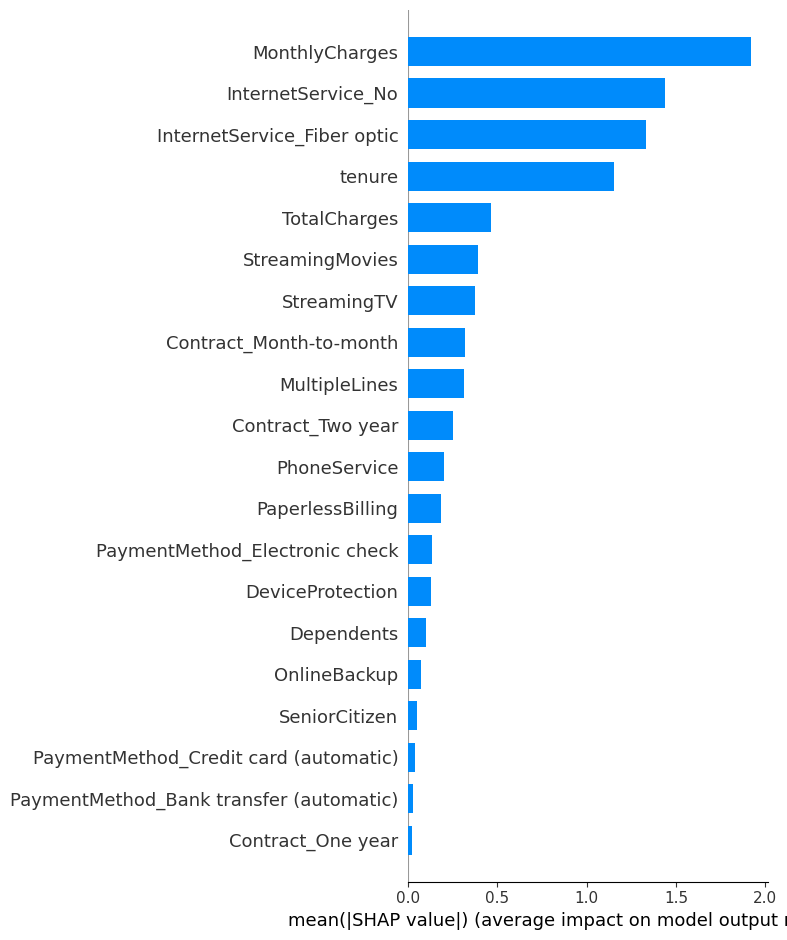

In [12]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type='bar',
    show=False
)
plt.savefig('../shap_summary.png', bbox_inches='tight')
plt.show()


Top 4 most influential features overall (bar plot):
* MonthlyCharges is by far the strongest predictor of churn, with the highest mean absolute SHAP value (~1.9), meaning it has the largest average impact on the model's churn predictions across all customers.
* InternetService_No and InternetService_Fiber optic are the second and third most important features — customers without internet service or on fiber optic plans behave very differently in terms of churn likelihood.
* tenure ranks fourth, confirming our EDA finding that how long a customer has been with the company is a strong churn signal.

C:\Users\acer\AppData\Local\Temp\ipykernel_14000\2493870159.py:1: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


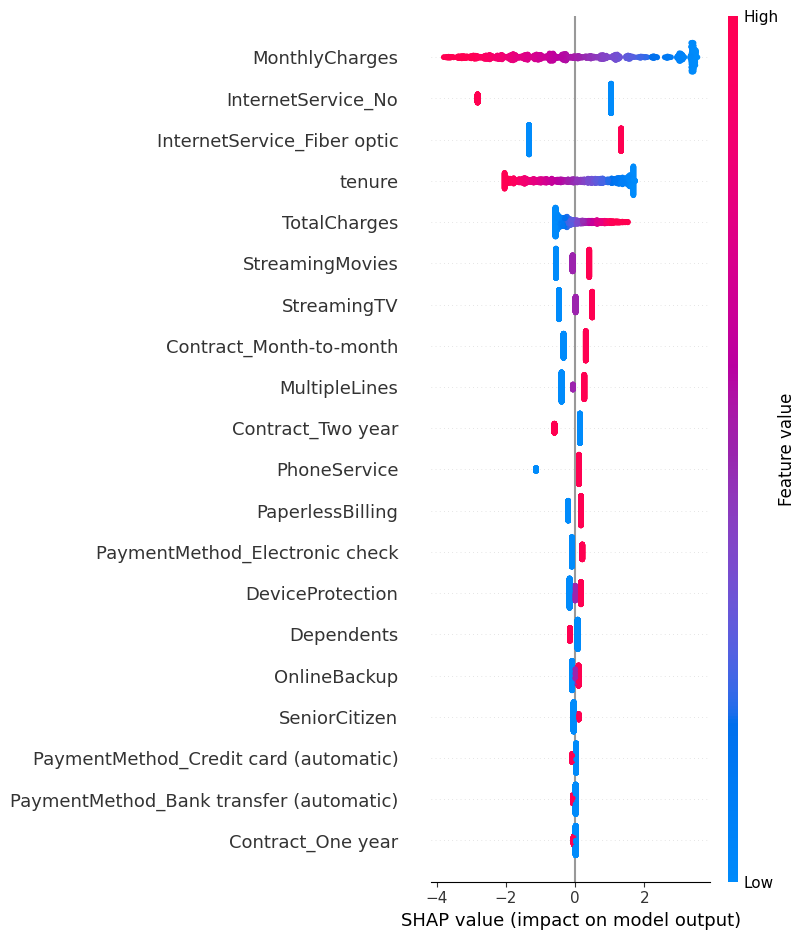

In [13]:
shap.summary_plot(
    shap_values,
    X_test,
    show=False,
    plot_type='dot'
)
plt.savefig('../shap_beeswarm.png', bbox_inches='tight')
plt.show()

* MonthlyCharges — red dots (high monthly charges) spread to the right (positive SHAP = increases churn probability), while blue dots (low charges) spread to the left (decreases churn probability). This confirms higher bills drive churn.
* InternetService_No — red dots sit to the left, meaning customers with no internet service (feature value = 1/"Yes") actually have lower churn risk — they're likely on simpler, cheaper plans.
* tenure — blue dots (low tenure = newer customers) push to the right (higher churn risk), red dots (long tenure) push to the left (lower churn risk). Perfectly consistent with our correlation of -0.35 found in EDA.
* TotalCharges — mostly blue dots pushing right, which makes sense since lower total charges often means newer customers who haven't built loyalty yet.
Key business insight: Monthly charges and internet service type dominate the model's predictions far more than contract type alone, suggesting that pricing strategy and service tier are the primary levers a business should focus on to reduce churn — not just pushing customers toward longer contracts.

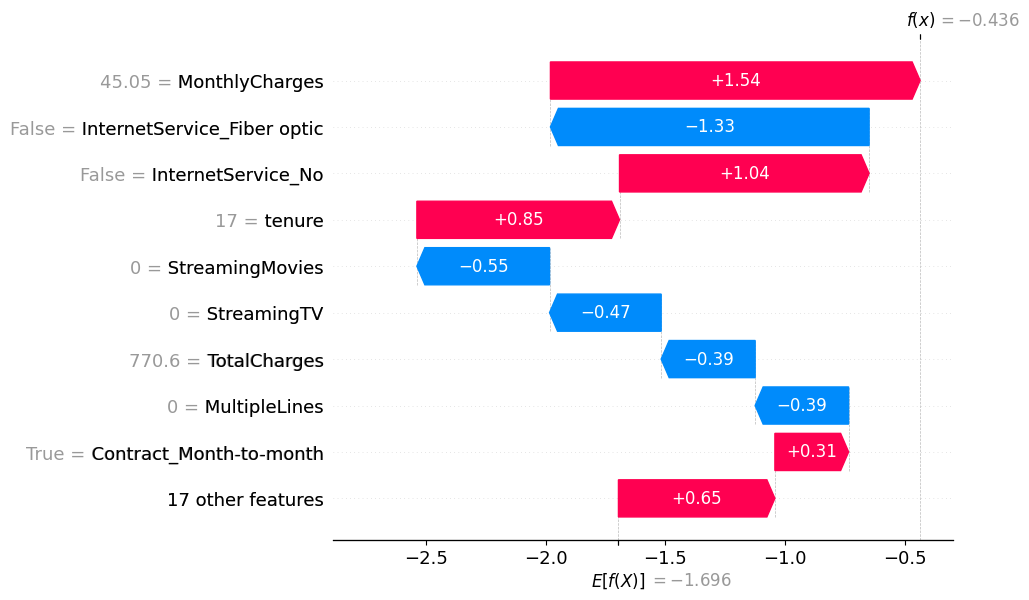

<Figure size 640x480 with 0 Axes>

In [14]:
position = list(y_test.index).index(y_test[y_test == 1].index[0])

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[position],
        base_values=explainer.expected_value,
        data=X_test.iloc[position].values,
        feature_names=X_test.columns.tolist()
    )
)
plt.savefig('../shap_waterfall.png', bbox_inches='tight')
plt.show()

SHAP Waterfall — Individual Customer Explanation
* This customer has a final model output of f(x) = -0.436, starting from a baseline of E[f(x)] = -1.696. While the model predicts this customer will likely stay, several risk factors push their churn probability upward:
* Monthly charges of $45.05 is the single largest churn risk factor (+1.54), followed by short tenure of only 17 months (+0.85) and a month-to-month contract (+0.31). The combination of these three factors alone contributes +2.70 toward churn risk.
* The strongest protective factors are the absence of fiber optic internet (-1.33) and no streaming subscriptions (-1.02 combined), which partially offset the risk factors.
* This demonstrates the model's ability to provide actionable, customer-level explanations — a business could use this output to identify which specific factors to address (e.g. offering a contract upgrade or a monthly charge discount) to retain this customer before they churn.

In [15]:
import pickle, json

pickle.dump(best_lr, open('../model.pkl', 'wb'))
pickle.dump(scaler, open('../scaler.pkl', 'wb'))
json.dump(X_train.columns.tolist(), open('../feature_names.json', 'w'))

print("model.pkl saved")
print("scaler.pkl saved")
print("feature_names.json saved")

model.pkl saved
scaler.pkl saved
feature_names.json saved
